In [1]:
import os
import glob
import datetime

import numpy as np
import pandas as pd

import jax
import numpyro

import hssm
import arviz as az
from scipy.stats import gaussian_kde

import matplotlib.pyplot as plt
import seaborn as sns

import sqlite3

/Users/javierrojas/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
query1 = "SELECT * FROM summaries"
query2 = "SELECT * FROM recovered_fits_2"
conn = sqlite3.connect("hssm_fits.db")

In [3]:
df1 = pd.read_sql_query(query1, conn)
df2= pd.read_sql_query(query2, conn)
conn.close()

In [4]:
df1

,param,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
0,v,0.513,0.174,0.213,0.866,0.010,0.007,312.0,261.0,1.01,935
1,t,0.637,0.060,0.516,0.728,0.004,0.003,232.0,402.0,1.01,935
2,a,1.004,0.078,0.860,1.140,0.005,0.003,294.0,491.0,1.01,935
3,z,0.506,0.048,0.408,0.588,0.002,0.002,498.0,339.0,1.00,935
4,v,0.634,0.150,0.347,0.903,0.008,0.005,396.0,539.0,1.01,1062
...,...,...,...,...,...,...,...,...,...,...,...
1367,a,1.159,0.066,1.051,1.283,0.004,0.003,373.0,465.0,1.01,1085
1368,v,0.483,0.144,0.229,0.765,0.006,0.004,619.0,537.0,1.00,1111
1369,z,0.425,0.041,0.351,0.502,0.002,0.001,589.0,587.0,1.00,1111
1370,t,0.464,0.047,0.373,0.541,0.004,0.003,177.0,244.0,1.02,1111


In [5]:
df2

,param,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id
0,v,0.179,0.068,0.046,0.299,0.004,0.003,377.0,535.0,1.00,765
1,z,0.588,0.023,0.547,0.636,0.001,0.001,346.0,355.0,1.00,765
2,t,0.708,0.026,0.662,0.754,0.001,0.001,444.0,582.0,1.00,765
3,a,1.299,0.038,1.228,1.373,0.002,0.001,609.0,622.0,1.00,765
4,v,0.694,0.079,0.540,0.824,0.004,0.003,404.0,529.0,1.01,1093
...,...,...,...,...,...,...,...,...,...,...,...
1367,z,0.572,0.027,0.524,0.626,0.001,0.001,391.0,433.0,1.01,1059
1368,v,0.390,0.077,0.247,0.519,0.003,0.002,580.0,597.0,1.01,1085
1369,a,1.151,0.036,1.085,1.221,0.001,0.001,588.0,571.0,1.00,1085
1370,t,1.162,0.023,1.120,1.208,0.001,0.001,466.0,548.0,1.00,1085


In [6]:
# Parameter Recovery Analysis

# Merge the dataframes on participant_id and param
recovery_df = pd.merge(
    df1.rename(columns={'mean': 'true_mean'}),
    df2.rename(columns={'mean': 'recovered_mean'}),
    on=['participant_id', 'param'],
    how='inner'
)

recovery_df.head()

ValueError: You are trying to merge on int64 and object columns for key 'participant_id'. If you wish to proceed you should use pd.concat

In [11]:
# Parameter Recovery Analysis

# First, check and fix data types
print("df1 dtypes:")
print(df1.dtypes)
print("\ndf2 dtypes:")
print(df2.dtypes)

# Convert participant_id to string in both dataframes to ensure consistency
df1['participant_id'] = df1['participant_id'].astype(str)
df2['participant_id'] = df2['participant_id'].astype(str)

# Merge the dataframes on participant_id and param
recovery_df = pd.merge(
    df1.rename(columns={'mean': 'true_mean'}),
    df2.rename(columns={'mean': 'recovered_mean'}),
    on=['participant_id', 'param'],
    how='inner'
)

print("Recovery DataFrame shape:", recovery_df.shape)
print("Parameters recovered:", recovery_df['param'].unique())
recovery_df.head()

df1 dtypes:
param              object
mean              float64
sd                float64
hdi_3%            float64
hdi_97%           float64
mcse_mean         float64
mcse_sd           float64
ess_bulk          float64
ess_tail          float64
r_hat             float64
participant_id      int64
dtype: object

df2 dtypes:
param              object
mean              float64
sd                float64
hdi_3%            float64
hdi_97%           float64
mcse_mean         float64
mcse_sd           float64
ess_bulk          float64
ess_tail          float64
r_hat             float64
participant_id     object
dtype: object
Recovery DataFrame shape: (1372, 20)
Parameters recovered: ['v' 't' 'a' 'z']


,param,true_mean,sd_x,hdi_3%_x,hdi_97%_x,mcse_mean_x,mcse_sd_x,ess_bulk_x,ess_tail_x,r_hat_x,participant_id,recovered_mean,sd_y,hdi_3%_y,hdi_97%_y,mcse_mean_y,mcse_sd_y,ess_bulk_y,ess_tail_y,r_hat_y
0,v,0.513,0.174,0.213,0.866,0.010,0.007,312.0,261.0,1.01,935,0.389,0.083,0.221,0.536,0.003,0.002,561.0,618.0,1.00
1,t,0.637,0.060,0.516,0.728,0.004,0.003,232.0,402.0,1.01,935,0.685,0.014,0.661,0.711,0.001,0.000,591.0,562.0,1.01
2,a,1.004,0.078,0.860,1.140,0.005,0.003,294.0,491.0,1.01,935,0.919,0.028,0.873,0.973,0.001,0.001,568.0,511.0,1.00
3,z,0.506,0.048,0.408,0.588,0.002,0.002,498.0,339.0,1.00,935,0.527,0.021,0.488,0.568,0.001,0.001,515.0,551.0,1.00
4,v,0.634,0.150,0.347,0.903,0.008,0.005,396.0,539.0,1.01,1062,0.617,0.078,0.478,0.769,0.004,0.003,424.0,640.0,1.02



Drift Rate (v) Recovery Statistics:
  Correlation: 0.963
  RMSE: 0.098
  Bias: 0.061
  N: 343


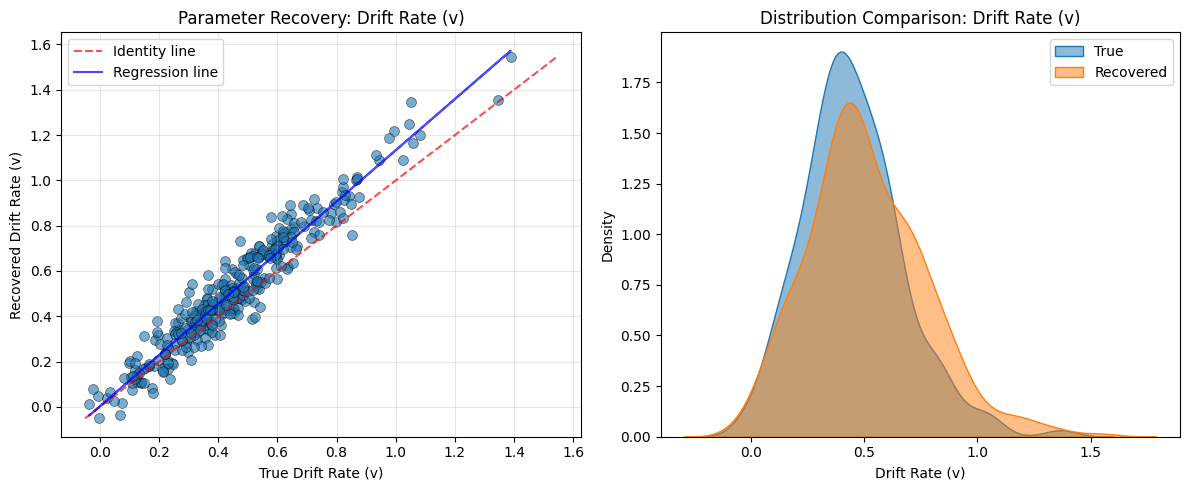


Boundary Separation (a) Recovery Statistics:
  Correlation: 0.972
  RMSE: 0.121
  Bias: 0.008
  N: 343


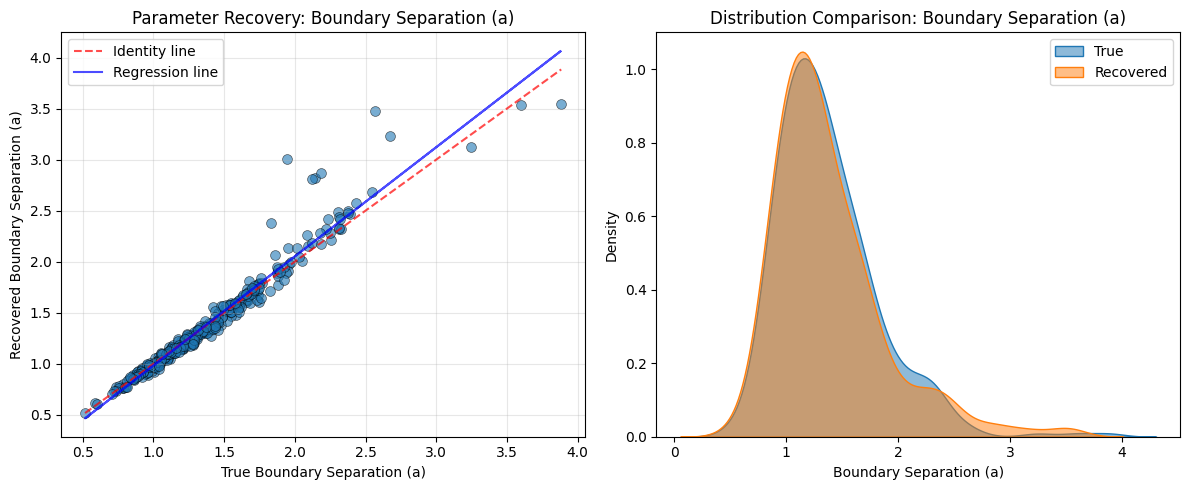


Starting Point (z) Recovery Statistics:
  Correlation: 0.932
  RMSE: 0.026
  Bias: -0.009
  N: 343


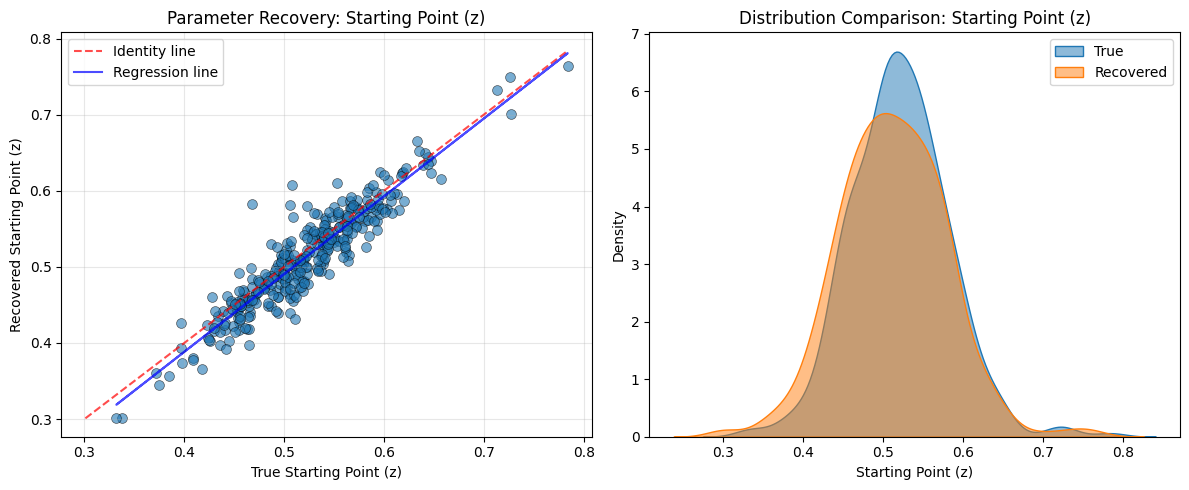


Non-decision Time (t) Recovery Statistics:
  Correlation: 0.990
  RMSE: 0.046
  Bias: 0.009
  N: 343


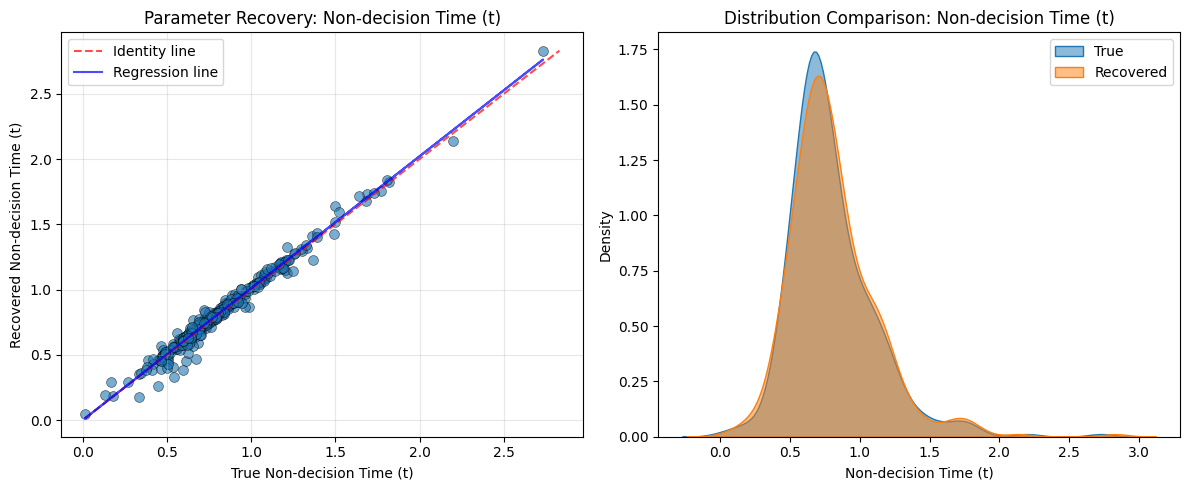

In [12]:
def plot_parameter_recovery(recovery_df, param_name, param_label):
    """Plot parameter recovery for a specific parameter"""
    param_data = recovery_df[recovery_df['param'] == param_name].copy()

    if len(param_data) == 0:
        print(f"No data for parameter {param_name}")
        return

    # Calculate statistics
    corr = param_data['true_mean'].corr(param_data['recovered_mean'])
    rmse = np.sqrt(np.mean((param_data['true_mean'] - param_data['recovered_mean'])**2))
    bias = np.mean(param_data['recovered_mean'] - param_data['true_mean'])

    # Create plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Scatter plot
    ax1.scatter(param_data['true_mean'], param_data['recovered_mean'],
               alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

    # Add identity line
    min_val = min(param_data['true_mean'].min(), param_data['recovered_mean'].min())
    max_val = max(param_data['true_mean'].max(), param_data['recovered_mean'].max())
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Identity line')

    # Add regression line
    z = np.polyfit(param_data['true_mean'], param_data['recovered_mean'], 1)
    p = np.poly1d(z)
    ax1.plot(param_data['true_mean'], p(param_data['true_mean']), 'b-', alpha=0.7, label='Regression line')

    ax1.set_xlabel(f'True {param_label}')
    ax1.set_ylabel(f'Recovered {param_label}')
    ax1.set_title(f'Parameter Recovery: {param_label}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Density plots
    sns.kdeplot(data=param_data['true_mean'], ax=ax2, label='True', fill=True, alpha=0.5)
    sns.kdeplot(data=param_data['recovered_mean'], ax=ax2, label='Recovered', fill=True, alpha=0.5)
    ax2.set_xlabel(param_label)
    ax2.set_ylabel('Density')
    ax2.set_title(f'Distribution Comparison: {param_label}')
    ax2.legend()

    plt.tight_layout()

    # Print statistics
    print(f"\n{param_label} Recovery Statistics:")
    print(f"  Correlation: {corr:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  Bias: {bias:.3f}")
    print(f"  N: {len(param_data)}")

    plt.show()

# Plot recovery for each parameter
param_labels = {
    'v': 'Drift Rate (v)',
    'a': 'Boundary Separation (a)',
    'z': 'Starting Point (z)',
    't': 'Non-decision Time (t)'
}

for param, label in param_labels.items():
    plot_parameter_recovery(recovery_df, param, label)

In [13]:
# Overall parameter recovery summary
print("=== PARAMETER RECOVERY SUMMARY ===")
print(f"Total participants recovered: {recovery_df['participant_id'].nunique()}")
print(f"Parameters analyzed: {recovery_df['param'].nunique()}")

# Summary statistics by parameter
summary_stats = []
for param in recovery_df['param'].unique():
    param_data = recovery_df[recovery_df['param'] == param]
    corr = param_data['true_mean'].corr(param_data['recovered_mean'])
    rmse = np.sqrt(np.mean((param_data['true_mean'] - param_data['recovered_mean'])**2))
    bias = np.mean(param_data['recovered_mean'] - param_data['true_mean'])

    summary_stats.append({
        'Parameter': param,
        'Correlation': corr,
        'RMSE': rmse,
        'Bias': bias,
        'N': len(param_data)
    })

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.round(3)
summary_df

=== PARAMETER RECOVERY SUMMARY ===
Total participants recovered: 343
Parameters analyzed: 4


,Parameter,Correlation,RMSE,Bias,N
0,v,0.963,0.098,0.061,343
1,t,0.990,0.046,0.009,343
2,a,0.972,0.121,0.008,343
3,z,0.932,0.026,-0.009,343


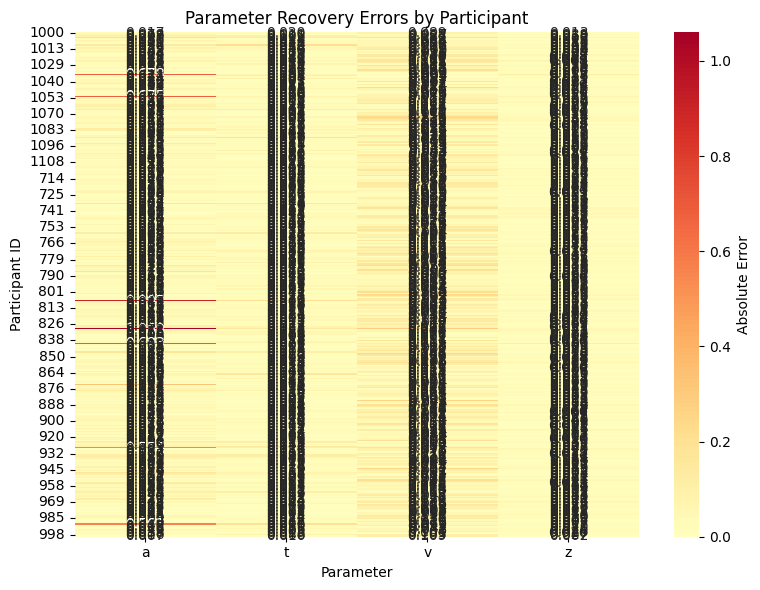


Error statistics by parameter:


param,a,t,v,z
count,343.000,343.000,343.000,343.000
mean,0.055,0.031,0.079,0.020
std,0.108,0.034,0.058,0.016
min,0.000,0.001,0.000,0.000
25%,0.015,0.010,0.030,0.008
50%,0.033,0.019,0.065,0.017
75%,0.057,0.038,0.118,0.029
max,1.060,0.214,0.295,0.115


In [14]:
# Additional analysis: Recovery quality heatmap
plt.figure(figsize=(8, 6))
recovery_pivot = recovery_df.pivot(index='participant_id', columns='param', values='recovered_mean')
true_pivot = recovery_df.pivot(index='participant_id', columns='param', values='true_mean')

# Calculate absolute errors
error_df = (recovery_pivot - true_pivot).abs()

# Create heatmap
sns.heatmap(error_df, cmap='RdYlBu_r', center=0, annot=True, fmt='.3f', cbar_kws={'label': 'Absolute Error'})
plt.title('Parameter Recovery Errors by Participant')
plt.ylabel('Participant ID')
plt.xlabel('Parameter')
plt.tight_layout()
plt.show()

print("\nError statistics by parameter:")
error_df.describe().round(3)

In [15]:
# Parameter Recovery Metrics Explanation
"""
PARAMETER RECOVERY METRICS EXPLANATION:

1. CORRELATION (r):
   - Measures the linear relationship between true and recovered parameters
   - Range: -1 to +1
   - Values closer to +1.0 indicate better recovery
   - r = 1.0 means perfect linear relationship (ideal recovery)
   - r = 0.0 means no linear relationship (poor recovery)

2. ROOT MEAN SQUARE ERROR (RMSE):
   - Measures the average magnitude of the errors in the recovered parameters
   - Units are the same as the parameter (e.g., if parameter is in seconds, RMSE is in seconds)
   - Lower values indicate better recovery
   - RMSE = 0 means perfect recovery (no errors)
   - Formula: sqrt(mean((true - recovered)²))

3. BIAS:
   - Measures systematic over- or under-estimation
   - Positive bias: recovered parameters are systematically higher than true values
   - Negative bias: recovered parameters are systematically lower than true values
   - Bias = 0 means no systematic error (unbiased recovery)
   - Formula: mean(recovered - true)

4. N (Sample Size):
   - Number of participants for which this parameter was recovered
   - Larger N gives more reliable estimates

INTERPRETATION GUIDELINES:
- Good recovery: Correlation > 0.8, RMSE small relative to parameter range, Bias close to 0
- Moderate recovery: Correlation 0.5-0.8, RMSE moderate, some bias acceptable
- Poor recovery: Correlation < 0.5, large RMSE, substantial bias

For DDM parameters:
- v (drift rate): Typically 0.5-2.0 range, RMSE < 0.2 is good
- a (boundary): Typically 1.0-3.0 range, RMSE < 0.3 is good
- z (starting point): Typically 0.3-0.7 range, RMSE < 0.1 is good
- t (non-decision time): Typically 0.1-0.5 range, RMSE < 0.05 is good
"""

print("Parameter Recovery Metrics Guide:")
print("=" * 50)
print(__doc__)

Parameter Recovery Metrics Guide:

PARAMETER RECOVERY METRICS EXPLANATION:

1. CORRELATION (r):
   - Measures the linear relationship between true and recovered parameters
   - Range: -1 to +1
   - Values closer to +1.0 indicate better recovery
   - r = 1.0 means perfect linear relationship (ideal recovery)
   - r = 0.0 means no linear relationship (poor recovery)

2. ROOT MEAN SQUARE ERROR (RMSE):
   - Measures the average magnitude of the errors in the recovered parameters
   - Units are the same as the parameter (e.g., if parameter is in seconds, RMSE is in seconds)
   - Lower values indicate better recovery
   - RMSE = 0 means perfect recovery (no errors)
   - Formula: sqrt(mean((true - recovered)²))

3. BIAS:
   - Measures systematic over- or under-estimation
   - Positive bias: recovered parameters are systematically higher than true values
   - Negative bias: recovered parameters are systematically lower than true values
   - Bias = 0 means no systematic error (unbiased recovery

In [16]:
# Interpretation of Your Results
print("=== INTERPRETATION OF YOUR PARAMETER RECOVERY RESULTS ===")

# Get the summary statistics
summary_stats = []
for param in recovery_df['param'].unique():
    param_data = recovery_df[recovery_df['param'] == param]
    corr = param_data['true_mean'].corr(param_data['recovered_mean'])
    rmse = np.sqrt(np.mean((param_data['true_mean'] - param_data['recovered_mean'])**2))
    bias = np.mean(param_data['recovered_mean'] - param_data['true_mean'])

    summary_stats.append({
        'Parameter': param,
        'Correlation': corr,
        'RMSE': rmse,
        'Bias': bias,
        'N': len(param_data)
    })

summary_df = pd.DataFrame(summary_stats)

# Interpretation function
def interpret_recovery(param, corr, rmse, bias):
    interpretation = f"\n{param.upper()} PARAMETER RECOVERY:\n"

    # Correlation interpretation
    if corr > 0.9:
        interpretation += f"✓ EXCELLENT correlation ({corr:.3f}) - Very strong linear relationship\n"
    elif corr > 0.8:
        interpretation += f"✓ GOOD correlation ({corr:.3f}) - Strong linear relationship\n"
    elif corr > 0.6:
        interpretation += f"~ MODERATE correlation ({corr:.3f}) - Acceptable relationship\n"
    elif corr > 0.3:
        interpretation += f"⚠ WEAK correlation ({corr:.3f}) - Poor relationship\n"
    else:
        interpretation += f"✗ VERY WEAK correlation ({corr:.3f}) - Very poor relationship\n"

    # RMSE interpretation (parameter-specific)
    rmse_thresholds = {
        'v': (0.1, 0.2),  # (good, acceptable)
        'a': (0.15, 0.3),
        'z': (0.05, 0.1),
        't': (0.02, 0.05)
    }

    if param in rmse_thresholds:
        good_rmse, accept_rmse = rmse_thresholds[param]
        if rmse < good_rmse:
            interpretation += f"✓ EXCELLENT RMSE ({rmse:.3f}) - Very accurate recovery\n"
        elif rmse < accept_rmse:
            interpretation += f"✓ ACCEPTABLE RMSE ({rmse:.3f}) - Reasonable accuracy\n"
        else:
            interpretation += f"⚠ HIGH RMSE ({rmse:.3f}) - Poor accuracy\n"

    # Bias interpretation
    bias_threshold = 0.05  # 5% of typical parameter range
    if abs(bias) < bias_threshold:
        interpretation += f"✓ LOW bias ({bias:.3f}) - Unbiased recovery\n"
    elif abs(bias) < bias_threshold * 2:
        interpretation += f"~ MODERATE bias ({bias:.3f}) - Some systematic error\n"
    else:
        interpretation += f"⚠ HIGH bias ({bias:.3f}) - Substantial systematic error\n"

    return interpretation

# Print interpretations for each parameter
for _, row in summary_df.iterrows():
    print(interpret_recovery(row['Parameter'], row['Correlation'], row['RMSE'], row['Bias']))

print("\n" + "="*60)
print("OVERALL ASSESSMENT:")
total_params = len(summary_df)
excellent_count = sum(1 for _, row in summary_df.iterrows() if row['Correlation'] > 0.8)
good_count = sum(1 for _, row in summary_df.iterrows() if 0.6 <= row['Correlation'] <= 0.8)

if excellent_count == total_params:
    print("🎉 EXCELLENT: All parameters recovered very well!")
elif excellent_count + good_count >= total_params * 0.75:
    print("✓ GOOD: Most parameters recovered adequately")
elif excellent_count + good_count >= total_params * 0.5:
    print("~ MODERATE: Some parameters need improvement")
else:
    print("⚠ POOR: Parameter recovery needs significant improvement")

print(f"\nParameters with excellent recovery: {excellent_count}/{total_params}")
print(f"Parameters with good/moderate recovery: {good_count}/{total_params}")
print(f"Parameters with poor recovery: {total_params - excellent_count - good_count}/{total_params}")

=== INTERPRETATION OF YOUR PARAMETER RECOVERY RESULTS ===

V PARAMETER RECOVERY:
✓ EXCELLENT correlation (0.963) - Very strong linear relationship
✓ EXCELLENT RMSE (0.098) - Very accurate recovery
~ MODERATE bias (0.061) - Some systematic error


T PARAMETER RECOVERY:
✓ EXCELLENT correlation (0.990) - Very strong linear relationship
✓ ACCEPTABLE RMSE (0.046) - Reasonable accuracy
✓ LOW bias (0.009) - Unbiased recovery


A PARAMETER RECOVERY:
✓ EXCELLENT correlation (0.972) - Very strong linear relationship
✓ EXCELLENT RMSE (0.121) - Very accurate recovery
✓ LOW bias (0.008) - Unbiased recovery


Z PARAMETER RECOVERY:
✓ EXCELLENT correlation (0.932) - Very strong linear relationship
✓ EXCELLENT RMSE (0.026) - Very accurate recovery
✓ LOW bias (-0.009) - Unbiased recovery


OVERALL ASSESSMENT:
🎉 EXCELLENT: All parameters recovered very well!

Parameters with excellent recovery: 4/4
Parameters with good/moderate recovery: 0/4
Parameters with poor recovery: 0/4


# Recovery stats

In [17]:
query = "SELECT * FROM recovered_fits_2"
conn = sqlite3.connect('hssm_fits.db')
df_all = pd.read_sql_query(query, conn)
conn.close()

# split dfs

In [18]:
df_v_all = df_all[df_all['param']=='v'] #drift
df_th_all = df_all[df_all['param']=='a'] #th
df_t_all = df_all[df_all['param']=='t'] #ndt
df_z_all = df_all[df_all['param']=='z'] #bias

In [19]:
df_v_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,0.511239,0.072017,0.378000,0.645472,0.003566,0.002548,426.093294,483.854227,1.005773
std,0.261485,0.017347,0.246128,0.280342,0.001085,0.000804,88.302262,99.253687,0.006299
min,-0.051000,0.026000,-0.161000,0.065000,0.001000,0.001000,96.000000,67.000000,1.000000
25%,0.341000,0.059000,0.227000,0.466000,0.003000,0.002000,371.000000,425.000000,1.000000
50%,0.480000,0.072000,0.355000,0.613000,0.003000,0.002000,430.000000,486.000000,1.010000
75%,0.676000,0.082000,0.541000,0.824500,0.004000,0.003000,484.500000,551.000000,1.010000
max,1.546000,0.132000,1.328000,1.777000,0.010000,0.007000,669.000000,771.000000,1.040000


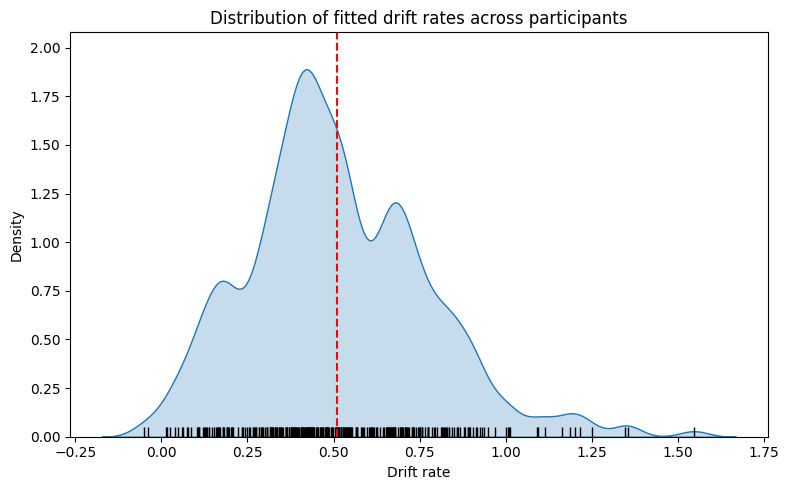

In [20]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_v_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_v_all['mean'], color='k')
plt.axvline(df_v_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Drift rate")
plt.ylabel("Density")
plt.title("Distribution of fitted drift rates across participants")
plt.tight_layout()
plt.show()

# th

In [21]:
df_th_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.00000,343.000000
mean,1.380155,0.060093,1.277493,1.493146,0.003388,0.002394,450.848397,484.51312,1.004985
std,0.499775,0.092646,0.427337,0.625193,0.007704,0.005568,97.027700,102.95695,0.005716
min,0.519000,0.015000,0.492000,0.547000,0.001000,0.000000,126.000000,104.00000,1.000000
25%,1.034000,0.034000,0.973000,1.096500,0.002000,0.001000,390.500000,426.50000,1.000000
50%,1.258000,0.042000,1.183000,1.342000,0.002000,0.001000,457.000000,495.00000,1.000000
75%,1.583500,0.056000,1.482500,1.696500,0.003000,0.002000,514.000000,553.00000,1.010000
max,3.547000,0.888000,3.293000,5.011000,0.077000,0.057000,697.000000,763.00000,1.030000


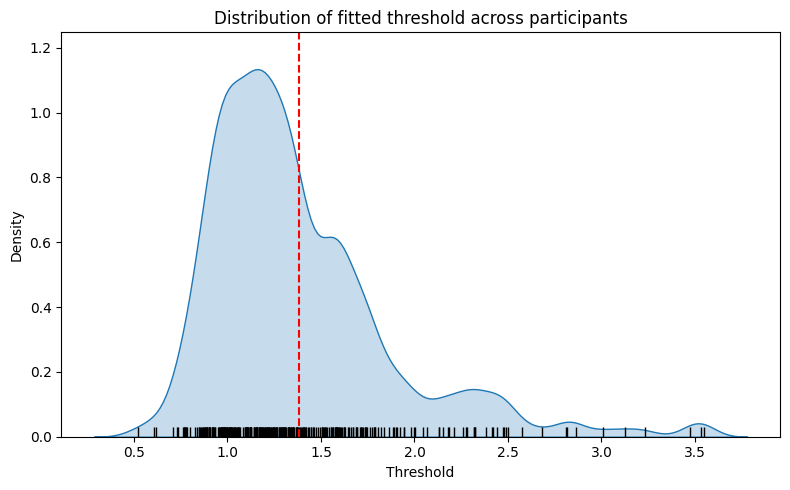

In [22]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_th_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_th_all['mean'], color='k')
plt.axvline(df_th_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Threshold")
plt.ylabel("Density")
plt.title("Distribution of fitted threshold across participants")
plt.tight_layout()
plt.show()

# ndt

In [23]:
df_t_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,0.807802,0.037207,0.738003,0.874362,0.002125,0.001504,399.947522,424.309038,1.006093
std,0.316392,0.028395,0.319705,0.321783,0.002062,0.001473,93.874419,118.330087,0.006615
min,0.049000,0.004000,0.000000,0.085000,0.000000,0.000000,88.000000,43.000000,1.000000
25%,0.616000,0.019000,0.581500,0.667000,0.001000,0.001000,337.500000,351.500000,1.000000
50%,0.755000,0.028000,0.694000,0.801000,0.001000,0.001000,404.000000,426.000000,1.010000
75%,0.935500,0.046000,0.870000,1.024000,0.002000,0.002000,458.000000,505.000000,1.010000
max,2.831000,0.183000,2.712000,2.952000,0.017000,0.012000,653.000000,742.000000,1.040000


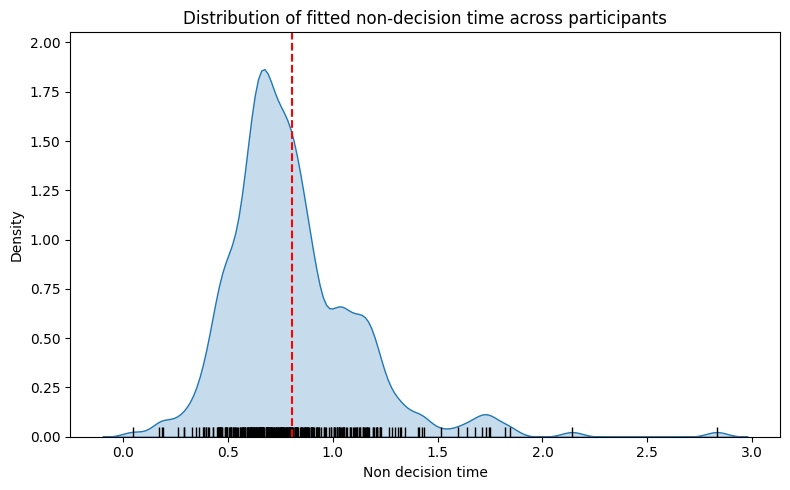

In [24]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_t_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_t_all['mean'], color='k')
plt.axvline(df_t_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Non decision time")
plt.ylabel("Density")
plt.title("Distribution of fitted non-decision time across participants")
plt.tight_layout()
plt.show()

# initial bias

In [25]:
df_z_all.describe()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
count,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000,343.000000
mean,0.511883,0.025099,0.465700,0.558548,0.001227,0.001082,407.408163,464.740525,1.006414
std,0.066806,0.009475,0.066387,0.071114,0.000852,0.000529,90.628295,98.021926,0.006642
min,0.301000,0.019000,0.269000,0.340000,0.001000,0.001000,84.000000,144.000000,1.000000
25%,0.467000,0.022000,0.421000,0.510500,0.001000,0.001000,350.500000,408.000000,1.000000
50%,0.510000,0.023000,0.461000,0.554000,0.001000,0.001000,404.000000,468.000000,1.010000
75%,0.555000,0.026000,0.509000,0.602000,0.001000,0.001000,459.500000,528.000000,1.010000
max,0.764000,0.107000,0.724000,0.796000,0.009000,0.006000,695.000000,716.000000,1.050000


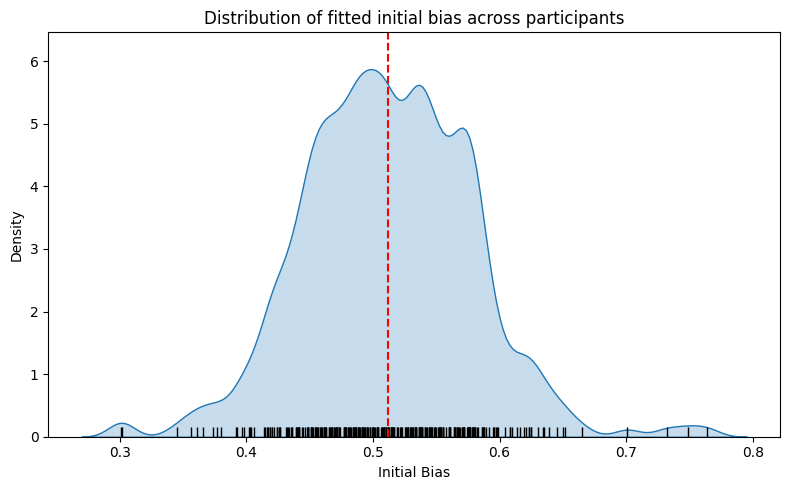

In [26]:
plt.figure(figsize=(8, 5))
sns.kdeplot(df_z_all['mean'], fill=True, bw_adjust=0.5)
sns.rugplot(df_z_all['mean'], color='k')
plt.axvline(df_z_all['mean'].mean(), color='red', linestyle='dashed')
plt.xlabel("Initial Bias")
plt.ylabel("Density")
plt.title("Distribution of fitted initial bias across participants")
plt.tight_layout()
plt.show()